In [9]:
!pip install netcdf4

   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   --- ------------------------------------ 0.5/7.0 MB 4.2 MB/s eta 0:00:02
   ------- -------------------------------- 1.3/7.0 MB 4.5 MB/s eta 0:00:02
   ------------ --------------------------- 2.1/7.0 MB 4.5 MB/s eta 0:00:02
   ------------------ --------------------- 3.1/7.0 MB 4.2 MB/s eta 0:00:01
   ------------------------- -------------- 4.5/7.0 MB 4.7 MB/s eta 0:00:01
   --------------------------------- ------ 5.8/7.0 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 5.1 MB/s eta 0:00:00


In [31]:
import pandas as pd
import numpy as np
import geopandas as gpd
import netCDF4 as nc
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt

In [13]:
# filepath = r'C:\Users\dpn_s\Downloads\VLM_Global_Imaged.nc'
# dataset = nc.Dataset(filepath)
# print(dataset.variables.keys())


dict_keys(['LonGrid', 'LatGrid', 'VU', 'SVU', 'ZETA'])


C:\Users\dpn_s\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\interactiveshell.py:3493: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


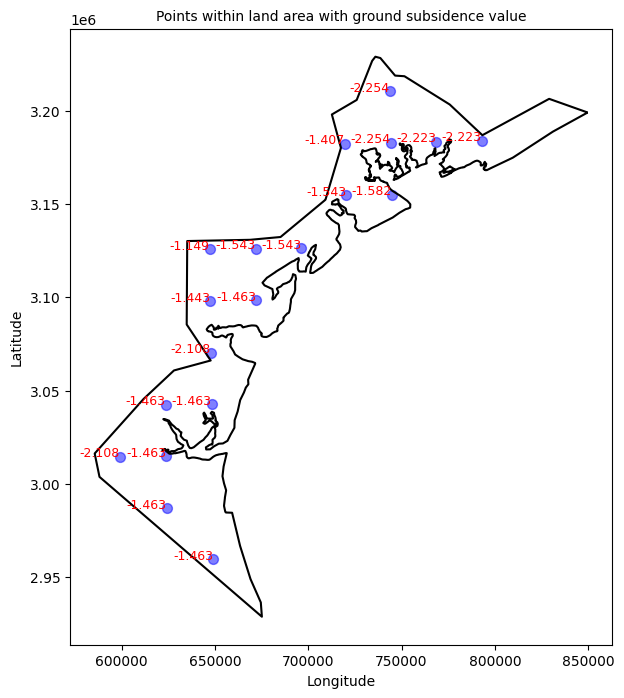

C:\Users\dpn_s\AppData\Local\Temp\ipykernel_9716\2378985453.py:45: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  points_within_polygon.to_file('D:\dipen\Ground_subsidence_data.shp')


In [39]:
shapefilepath = r"D:\dipen\land_Part_area_utm.zip"
column_names = ['longitude', 'latitude', 'VU', 'SVU', 'ZETA']  # Add more column names if needed
df = pd.read_csv('E:\PhD Research\Vertical land motion\VLM_Global_Imaged.txt', delim_whitespace=True, header=None, names=column_names)
# Create a 'geometry' column with Point objects
df['geometry'] = df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)

# # Convert the DataFrame to a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry')

# Set the coordinate reference system (CRS) to WGS84
gdf.set_crs(epsg=4326, inplace=True)
# gdf.plot()

# Load the point and polygon shapefiles
points_gdf = gdf  # WGS 84 (EPSG:4326)
polygon_gdf = gpd.read_file(shapefilepath) # WGS 84 UTM Zone 14N (EPSG:32614)

# Reproject points GeoDataFrame to match the polygon's CRS
points_gdf = points_gdf.to_crs(polygon_gdf.crs)

# Perform the spatial intersection
points_within_polygon = gpd.sjoin(points_gdf, polygon_gdf, op='within')
# points_within_polygon.plot()
# Plot the points with their VU labels
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the points
points_within_polygon.plot(ax=ax, color='blue', markersize=50, alpha=0.5)

# Add labels for the VU attribute
for x, y, label in zip(points_within_polygon.geometry.x, points_within_polygon.geometry.y, points_within_polygon['VU']):
    ax.text(x, y, str(label), fontsize=9, ha='right', color='red')

# Optionally, plot the polygon boundaries
polygon_gdf.boundary.plot(ax=ax, edgecolor='black')

# Customize the plot (title, axis labels, etc.)
ax.set_title('Points within land area with ground subsidence value', fontsize=10)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

# Save the result to a new shapefile
points_within_polygon.to_file('D:\dipen\Ground_subsidence_data.shp')



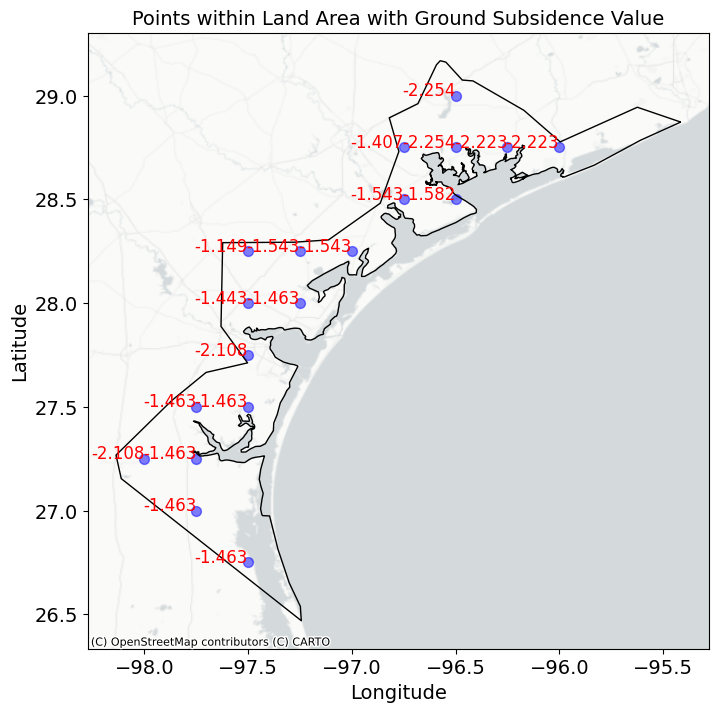

In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx

# File paths
shapefilepath = r"D:\dipen\land_Part_area_utm.zip"
column_names = ['longitude', 'latitude', 'VU', 'SVU', 'ZETA']  # Add more column names if needed
df = pd.read_csv(r'E:\PhD Research\Vertical land motion\VLM_Global_Imaged.txt', delim_whitespace=True, header=None, names=column_names)

# Create a 'geometry' column with Point objects
df['geometry'] = df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)

# Convert the DataFrame to a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry')

# Set the coordinate reference system (CRS) to WGS84
gdf.set_crs(epsg=4326, inplace=True)

# Load the point and polygon shapefiles
points_gdf = gdf  # WGS 84 (EPSG:4326)
polygon_gdf = gpd.read_file(shapefilepath)  # WGS 84 UTM Zone 14N (EPSG:32614)

# Reproject points GeoDataFrame to match the polygon's CRS
points_gdf = points_gdf.to_crs(polygon_gdf.crs)

# Perform the spatial intersection
points_within_polygon = gpd.sjoin(points_gdf, polygon_gdf, predicate='within')

# Reproject everything to EPSG:4326 (lat/long) for base map compatibility
points_within_polygon = points_within_polygon.to_crs(epsg=4326)
polygon_gdf = polygon_gdf.to_crs(epsg=4326)

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the polygon boundaries
polygon_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

# Plot the points
points_within_polygon.plot(ax=ax, color='blue', markersize=50, alpha=0.5)

# Add labels for the VU attribute
for x, y, label in zip(points_within_polygon.geometry.x, points_within_polygon.geometry.y, points_within_polygon['VU']):
    ax.text(x, y, str(label), fontsize=12, ha='right', color='red')

# Add a base map using contextily
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:4326")

# Customize the plot
ax.set_title('Points within Land Area with Ground Subsidence Value', fontsize=14)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)  # Increase tick label size

# Show the plot
plt.show()


In [17]:
!pip install contextily

Defaulting to user installation because normal site-packages is not writeable
  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mercantile-1.2.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached geographiclib-2.0-py3-none-any.whl.metadata (1.4 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
   ---------------------------------------- 0.0/301.8 kB ? eta -:--:--
   ----- ---------------------------------- 41.0/301.8 kB 2.0 MB/s eta 0:00:01
   ---------------------------------------  297.0/301.8 kB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 301.8/301.8 kB 3.7 MB/s eta 0:00:00
Using cached mercantile-1.2.1-py3-none-any.whl (14 kB)
   ---------------------------------------- 0.0/88.4 kB ? eta -:--:--
   ---------------------------------------- 88.4/88.4 kB 2.5 MB/s eta 0:00:00
Using cached geographiclib-2.0-py3-none-any.whl (40 kB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


C:\Users\sahad2\AppData\Local\Temp\ipykernel_6532\2262818264.py:34: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf = gdf[gdf.geometry.within(polygon_gdf.unary_union)]
C:\Users\sahad2\AppData\Local\Temp\ipykernel_6532\2262818264.py:54: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid_points['inside'] = grid_points.geometry.within(polygon_gdf.unary_union)


CRSError: The EPSG code is unknown. PROJ: proj_create_from_database: C:\Program Files\PostgreSQL\15\share\contrib\postgis-3.4\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 4 is expected. It comes from another PROJ installation.

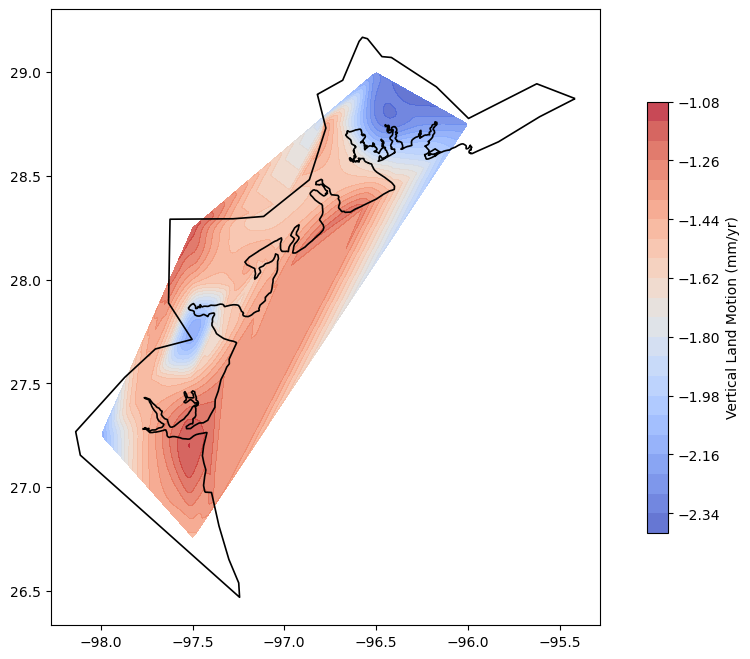

In [11]:


# Add basemap
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from shapely.geometry import Point
import contextily as ctx
from scipy.interpolate import griddata
import pyproj

# File paths
shapefilepath = r"D:\dipen\land_Part_area_utm.zip"
vlm_filepath = r"D:\Phd Research\Data\VLM data\VLM_Global_Imaged.txt"

# Read VLM data
column_names = ['longitude', 'latitude', 'VU', 'SVU', 'ZETA']
df = pd.read_csv(vlm_filepath, delim_whitespace=True, header=None, names=column_names)

# Convert to GeoDataFrame
df['geometry'] = df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")  # Ensure correct CRS

# Load land boundary shapefile and reproject to WGS 84
polygon_gdf = gpd.read_file(shapefilepath).to_crs(epsg=4326)

# Ensure polygon validity
polygon_gdf = polygon_gdf.buffer(0)

# Remove duplicate points to avoid triangulation issues
gdf = gdf.drop_duplicates(subset=['longitude', 'latitude'])

# Select only points inside the land boundary
gdf = gdf[gdf.geometry.within(polygon_gdf.unary_union)]

# Extract coordinate and VLM values
X, Y, Z = gdf.geometry.x.values, gdf.geometry.y.values, gdf['VU'].values

# Define grid based on land boundary extent
xmin, ymin, xmax, ymax = polygon_gdf.total_bounds
grid_x, grid_y = np.meshgrid(
    np.linspace(xmin, xmax, 300),
    np.linspace(ymin, ymax, 300)
)

# Perform Interpolation using griddata (more stable than Triangulation)
grid_z = griddata((X, Y), Z, (grid_x, grid_y), method='cubic')

# Convert grid points to GeoDataFrame
grid_points = gpd.GeoDataFrame(geometry=[Point(x, y) for x, y in zip(grid_x.flatten(), grid_y.flatten())], crs="EPSG:4326")
grid_points['values'] = grid_z.flatten()

# Mask values outside the polygon
grid_points['inside'] = grid_points.geometry.within(polygon_gdf.unary_union)
grid_points.loc[~grid_points['inside'], 'values'] = np.nan  # Set NaN outside polygon

# Extract masked values for plotting
grid_x, grid_y, grid_z = grid_x.flatten(), grid_y.flatten(), grid_points['values'].values

# Remove NaN values for better visualization
valid_mask = ~np.isnan(grid_z)
grid_x, grid_y, grid_z = grid_x[valid_mask], grid_y[valid_mask], grid_z[valid_mask]

# Plot interpolated surface
fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.tricontourf(grid_x, grid_y, grid_z, levels=20, cmap='coolwarm', alpha=0.8)

# Overlay land boundary
polygon_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=1.2)

# Add colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label("Vertical Land Motion (mm/yr)")

# Add basemap
ctx.add_basemap(ax, crs=pyproj.CRS(4326), source=ctx.providers.CartoDB.PositronNoLabels)


# Labels and title
ax.set_title('IDW Interpolated Surface Map of VLM (Lat/Lon in WGS 84)', fontsize=14)
ax.set_xlabel("Longitude (°)", fontsize=12)
ax.set_ylabel("Latitude (°)", fontsize=12)

plt.show()




In [ ]:
!pip uninstall rasterio
!pip install rasterio --no-cache-dir
